## SARIMAX

**Objetivo:** desenvolver um modelo de previsão de PM2.5 utilizando SARIMAX, incorporando variáveis meteorológicas e sazonalidades temporais para previsão das próximas 24 horas.

*******
**Exploração e entendimento dos dados**
- Avaliando ciclos sazonais e correlação entre variáveis
- VIF (variáveis atmosféricas)
- Estacionaridade

************

**Experimentos SARIMAX**

Foram realizados diversos experimentos com o modelo SARIMAX para previsão de PM2.5 com horizonte de 24 horas. Os testes avaliaram diferentes configurações de:

- Tamanho do conjunto de treinamento (50%, 70%, 90% e 100% dos dados);
- Estratégias de tratamento de dados faltantes (sem interpolação, interpolação para gaps menores que 12 horas e preenchimento completo por média);
- Inclusão de variáveis exógenas meteorológicas (temperatura, umidade relativa, precipitação e velocidade do vento);
- Diferentes combinações dos parâmetros order (p,d,q) e seasonal_order (P,D,Q,24).
- Inclusão de variáveis exógenas sazonais (sin/cos do mês/dia/hora e séries de Fourier)

************

**Melhor Experimento**

- SARIMAX:
    order = (1,0,1) 
    seasonal_order = (0,1,1,24)

- Conjunto de dados: 100% dos dados (2016-2019) 

- Variáveis exógenas:
Temperatura do ar,
Umidade relativa,
Precipitação e
Velocidade do vento

- Interpolação: Sem interpolação

- Conjunto de dados:

      - train: (16104, 7) 2016-03-01 00:00:00+00:00 2017-12-31 23:00:00+00:00
      - val  : (8760, 7) 2018-01-01 00:00:00+00:00 2018-12-31 23:00:00+00:00
      - test : (5499, 7) 2019-01-01 00:00:00+00:00 2019-08-18 02:00:00+00:00

- Resultados obtidos no conjunto de validação em média:

    - MAE: 7.13 µg/m³
    - RMSE: 8,61 µg/m³
    - R²: -0.26

- Resultados obtidos no conjunto de teste em média:

    - MAE: 7.30 µg/m³
    - RMSE: 9.48 µg/m³
    - R²: -0.44

Os valores de R² negativos indicam que o modelo performa pior que a média da série na representação da variabilidade do target. Isso pode estar associado a característica linear do modelo SARIMAX, dessa forma, também serão utilizados modelos como XGBOOST e LSTM.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy import stats

### 1. Carregamento dos dados

In [2]:
# abrindo base de dados para treinamento/teste/validação
data = pd.read_csv("../data/data_sem_interpolacao/dados_full_feature_2016_2019_nan.csv")
data.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134
1,2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915
2,2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134
3,2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623
4,2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984


In [3]:
data["time"] = pd.to_datetime(data["time"])
data = data.set_index("time").sort_index()

data.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
time,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984


### 2. Exploração da Série Temporal (Ciclos)

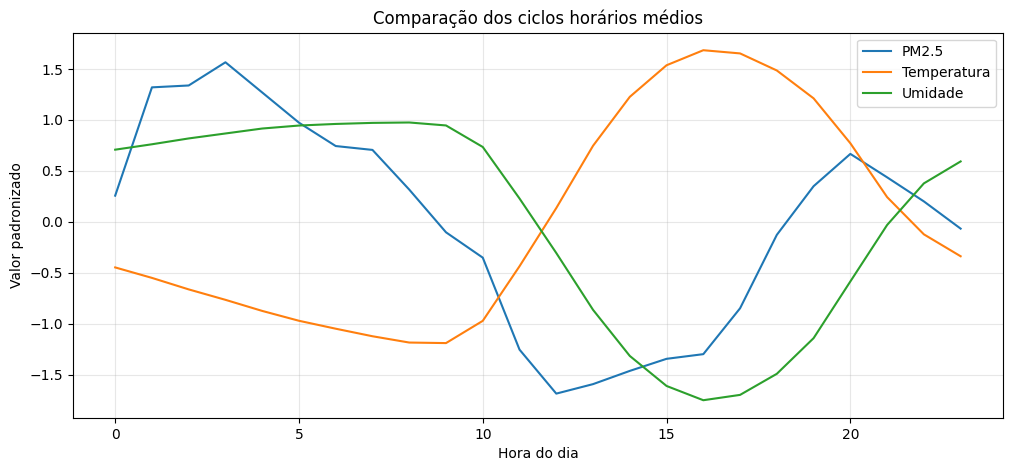

In [4]:
#ciclo diário
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.hour)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.hour)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.hour)["relative_humidity_2m"].mean()
})

ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos horários médios")
ax.set_xlabel("Hora do dia")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.show()

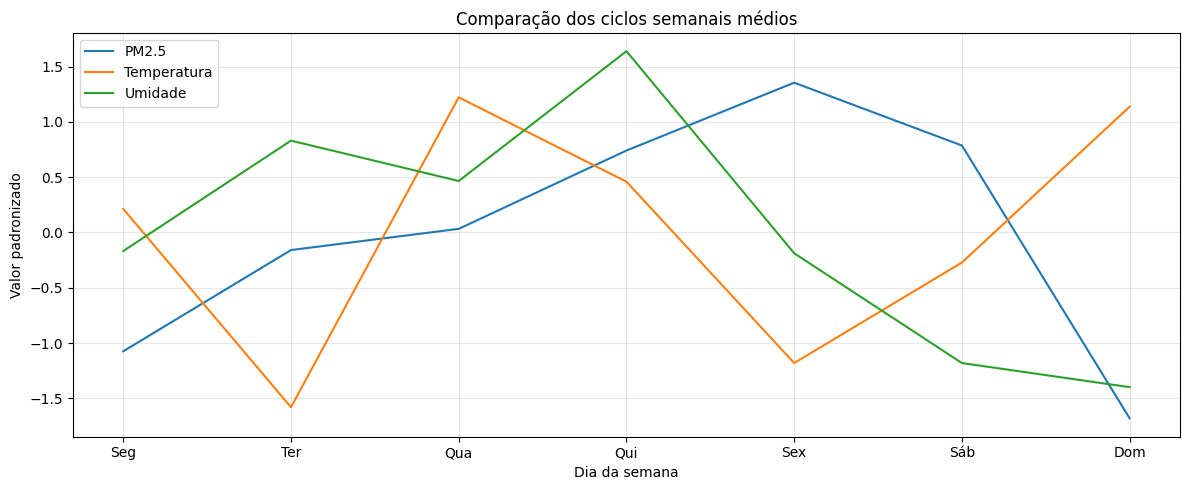

In [5]:
# ciclo semanal
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.dayofweek)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.dayofweek)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.dayofweek)["relative_humidity_2m"].mean()
})

ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
ciclo_norm.index = dias

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos semanais médios")
ax.set_xlabel("Dia da semana")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

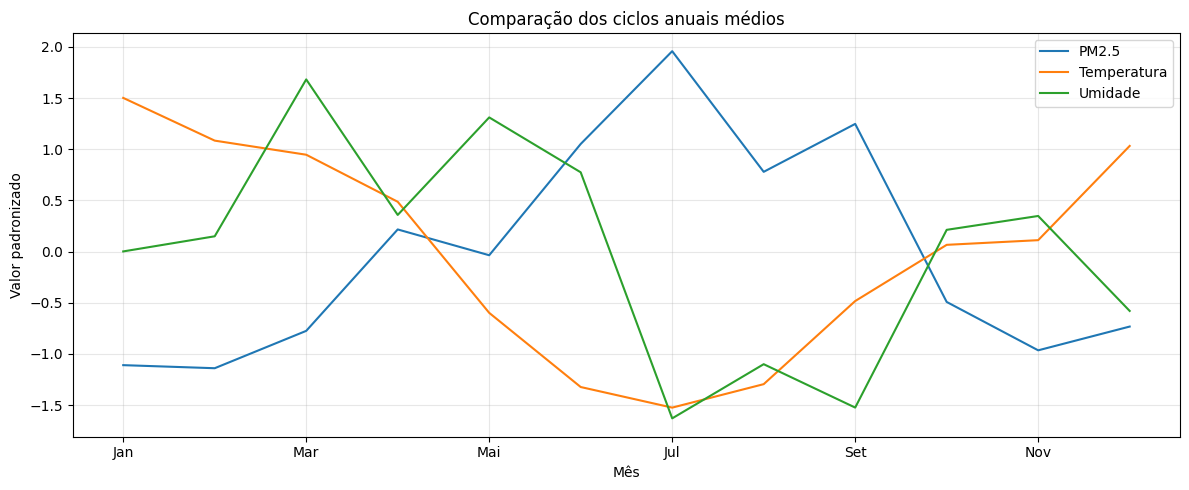

In [6]:
# ciclo anual
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.month)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.month)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.month)["relative_humidity_2m"].mean()
})


ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

meses = [
    "Jan", "Fev", "Mar", "Abr",
    "Mai", "Jun", "Jul", "Ago",
    "Set", "Out", "Nov", "Dez"
]

ciclo_norm.index = meses

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos anuais médios")
ax.set_xlabel("Mês")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3. Correlação entre variáveis

In [7]:
######### Temperatura e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_temp = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["temperature_2m"].shift(lag)
    )

    corr_temp.append(c)

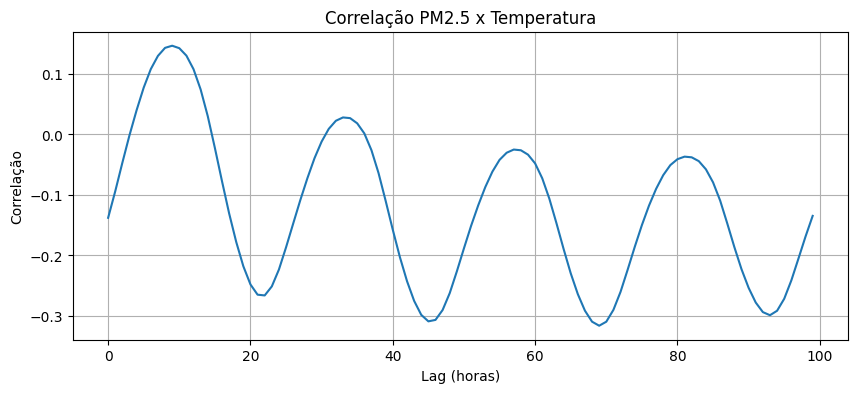

In [8]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_temp)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x Temperatura")
plt.grid()

plt.show()

In [9]:
######### umidade e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_umi = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["relative_humidity_2m"].shift(lag)
    )

    corr_umi.append(c)

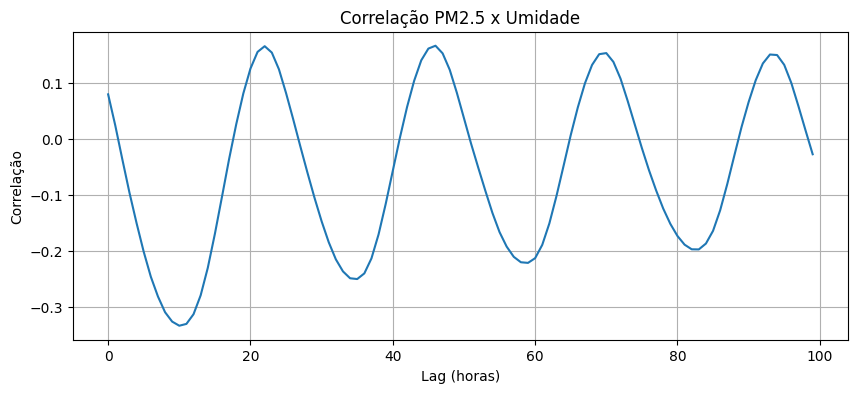

In [10]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_umi)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x Umidade")
plt.grid()

plt.show()

In [11]:
corr_pm25 = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["MP2.5"].shift(lag)
    )

    corr_pm25.append(c)

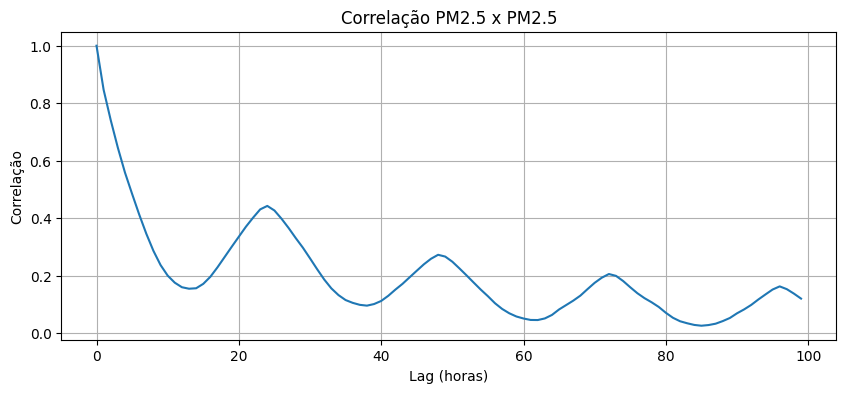

In [12]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_pm25)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x PM2.5")
plt.grid()

plt.show()

In [13]:
######### umidade e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_umi_temp = []

for lag in range(0, 100):

    c = data["temperature_2m"].corr(
        data["relative_humidity_2m"].shift(lag)
    )

    corr_umi_temp.append(c)

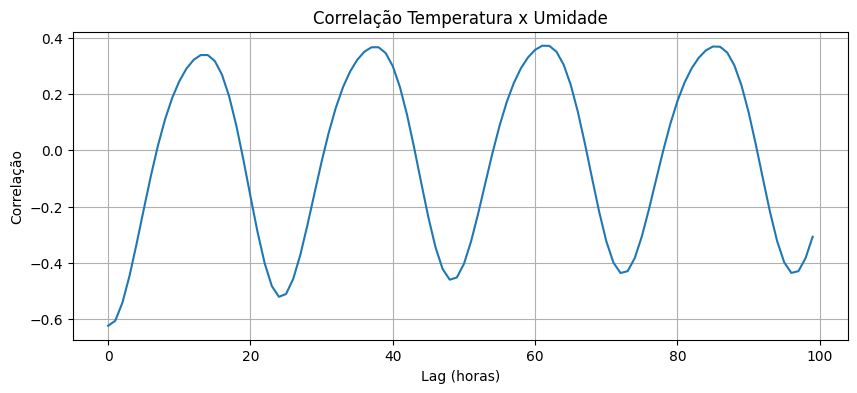

In [14]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_umi_temp)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação Temperatura x Umidade")
plt.grid()

plt.show()

### 4. VIF (Variance Inflation Factor): Investigando multicolinearidade entre as features

In [15]:
# normalizando utilizando StandardScaler()
cols = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "wind_speed_10m"]

scaler = StandardScaler()

data_scaled = data.drop(columns=["MP2.5"]).copy()
#data_scaled = data.copy()

data_scaled[cols] = scaler.fit_transform(
    data_scaled[cols]
)

data_scaled.head()

,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
time,,,,
2016-03-01 00:00:00+00:00,-0.303972,0.807668,1.401177,0.345426
2016-03-01 01:00:00+00:00,-0.292856,0.867885,0.426766,0.687281
2016-03-01 02:00:00+00:00,-0.281741,0.827881,0.264364,0.345426
2016-03-01 03:00:00+00:00,-0.303972,0.887937,0.751570,0.171646
2016-03-01 04:00:00+00:00,-0.292856,0.867885,0.589168,0.421262


In [16]:
#Considerar VIF ≥  10 como um potencial problema

df = pd.DataFrame()

df["features"] = data_scaled.columns

df["vif_index"] = [vif(data_scaled.values, i) for i in range(data_scaled.shape[1])]

round(df.sort_values(by="vif_index", ascending = False),2)

,features,vif_index
1,relative_humidity_2m,1.71
0,temperature_2m,1.68
3,wind_speed_10m,1.04
2,precipitation,1.02


### 5. Entendendo estacionaridade e defasegem de PM2.5

In [17]:
# Avaliando período máximo contínuo sem gaps temporais para análise.
# Tentei fazer a análise com a série completa mas como tem gaps quis comparar também com uma série contínua
# para ter certeza que os gaps não estavam influenciando as estimativas, principalmente da estacionaridade.

def encontrar_segmentos_continuos(df, col="MP2.5", freq="h"):
    serie = df[col].copy()

    serie = serie.sort_index().asfreq(freq)

    valido = serie.notna()

    grupo = (valido != valido.shift()).cumsum()

    segmentos = []

    for _, bloco in serie.groupby(grupo):
        if bloco.notna().all():
            segmentos.append({
                "inicio": bloco.index[0],
                "fim": bloco.index[-1],
                "n_horas": len(bloco),
                "n_dias": len(bloco) / 24
            })

    segmentos = pd.DataFrame(segmentos)

    if segmentos.empty:
        return segmentos

    return segmentos.sort_values("n_horas", ascending=False).reset_index(drop=True)

In [18]:
segmentos = encontrar_segmentos_continuos(data, col="MP2.5", freq="h")
segmentos.head(10)

,inicio,fim,n_horas,n_dias
0,2016-11-08 18:00:00+00:00,2017-03-31 05:00:00+00:00,3420,142.500000
1,2019-03-05 17:00:00+00:00,2019-05-30 11:00:00+00:00,2059,85.791667
2,2018-12-26 15:00:00+00:00,2019-03-05 14:00:00+00:00,1656,69.000000
3,2017-11-07 14:00:00+00:00,2018-01-14 19:00:00+00:00,1638,68.250000
4,2017-05-04 17:00:00+00:00,2017-07-10 12:00:00+00:00,1604,66.833333
5,2018-04-05 12:00:00+00:00,2018-06-04 22:00:00+00:00,1451,60.458333
6,2018-01-17 03:00:00+00:00,2018-03-14 22:00:00+00:00,1364,56.833333
7,2016-07-17 12:00:00+00:00,2016-08-31 10:00:00+00:00,1079,44.958333
8,2016-05-01 16:00:00+00:00,2016-06-10 02:00:00+00:00,947,39.458333
9,2018-06-19 03:00:00+00:00,2018-07-24 19:00:00+00:00,857,35.708333


In [19]:
maior = segmentos.iloc[0]

inicio = maior["inicio"]
fim = maior["fim"]

data_continua = data.loc[inicio:fim].copy()

print(inicio, fim)
print(f"{maior['n_dias']:.1f} dias contínuos")

2016-11-08 18:00:00+00:00 2017-03-31 05:00:00+00:00
142.5 dias contínuos


In [20]:
# Avaliando impactos diretos e indiretos de PM2.5
def plot_autocorrelation(y, d=0, D=0, m=0):
    y = pd.Series(y)
    if D > 0:
        for i in range(D):
            y = y.diff(m)
    if d > 0:
        for i in range(d):
            y = y.diff(1)
    fig = plt.figure(figsize=(20,10))
    ax1 = fig.add_subplot(2,1,1)
    ax2 = fig.add_subplot(2,2,3)
    ax3 = fig.add_subplot(2,2,4)
    ax1.plot(y)
    plot_acf(y, lags = 50, ax=ax2);
    plot_pacf(y, lags=50, method='ywm', ax=ax3, color='r');
    plt.show()

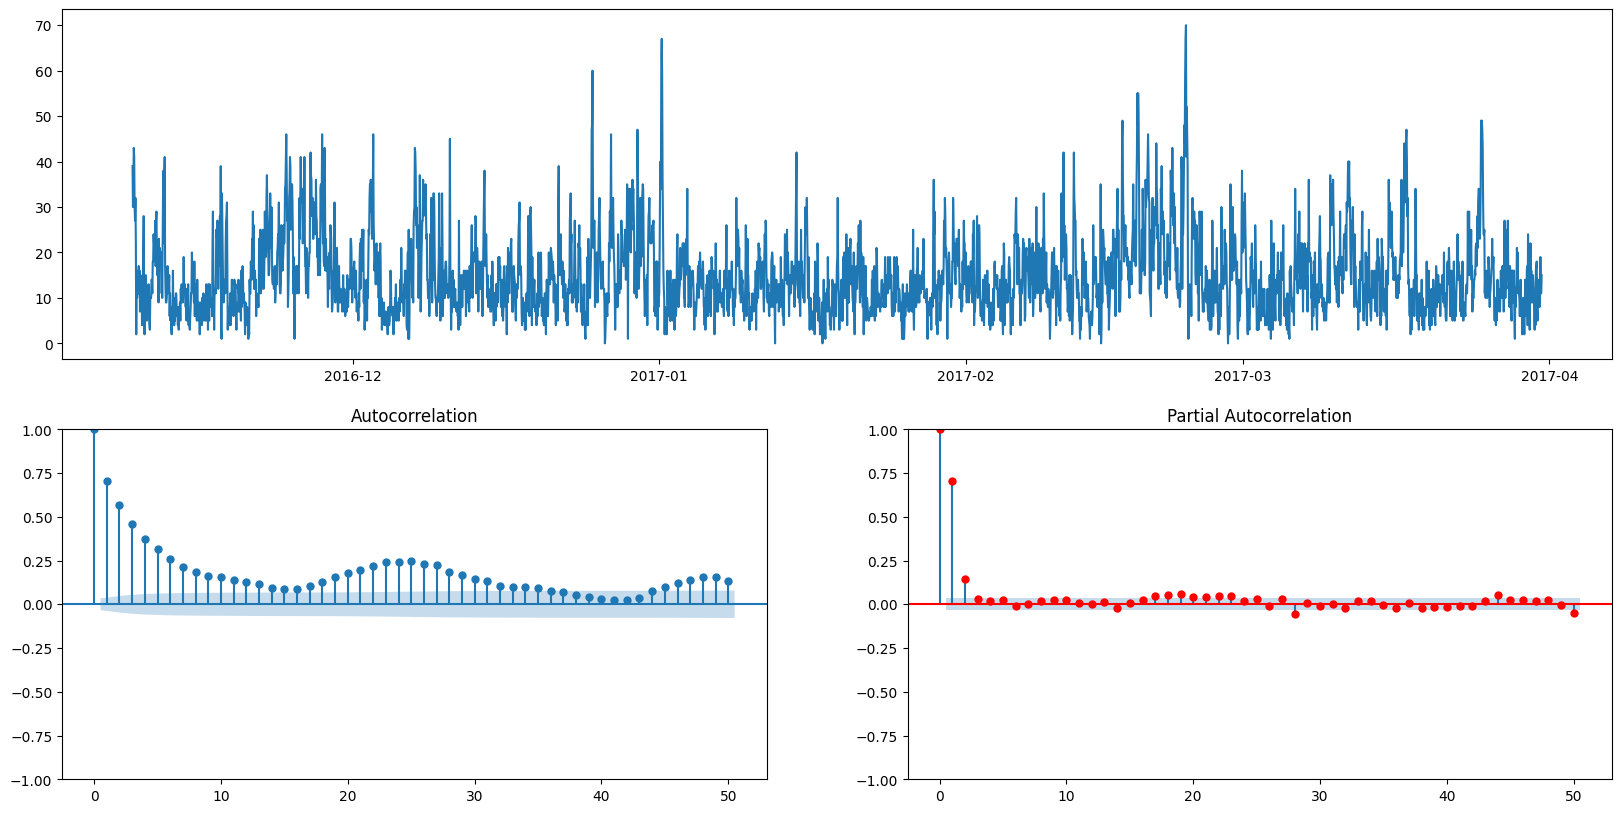

In [21]:
plot_autocorrelation(data_continua["MP2.5"], d=0, D=0, m=24)

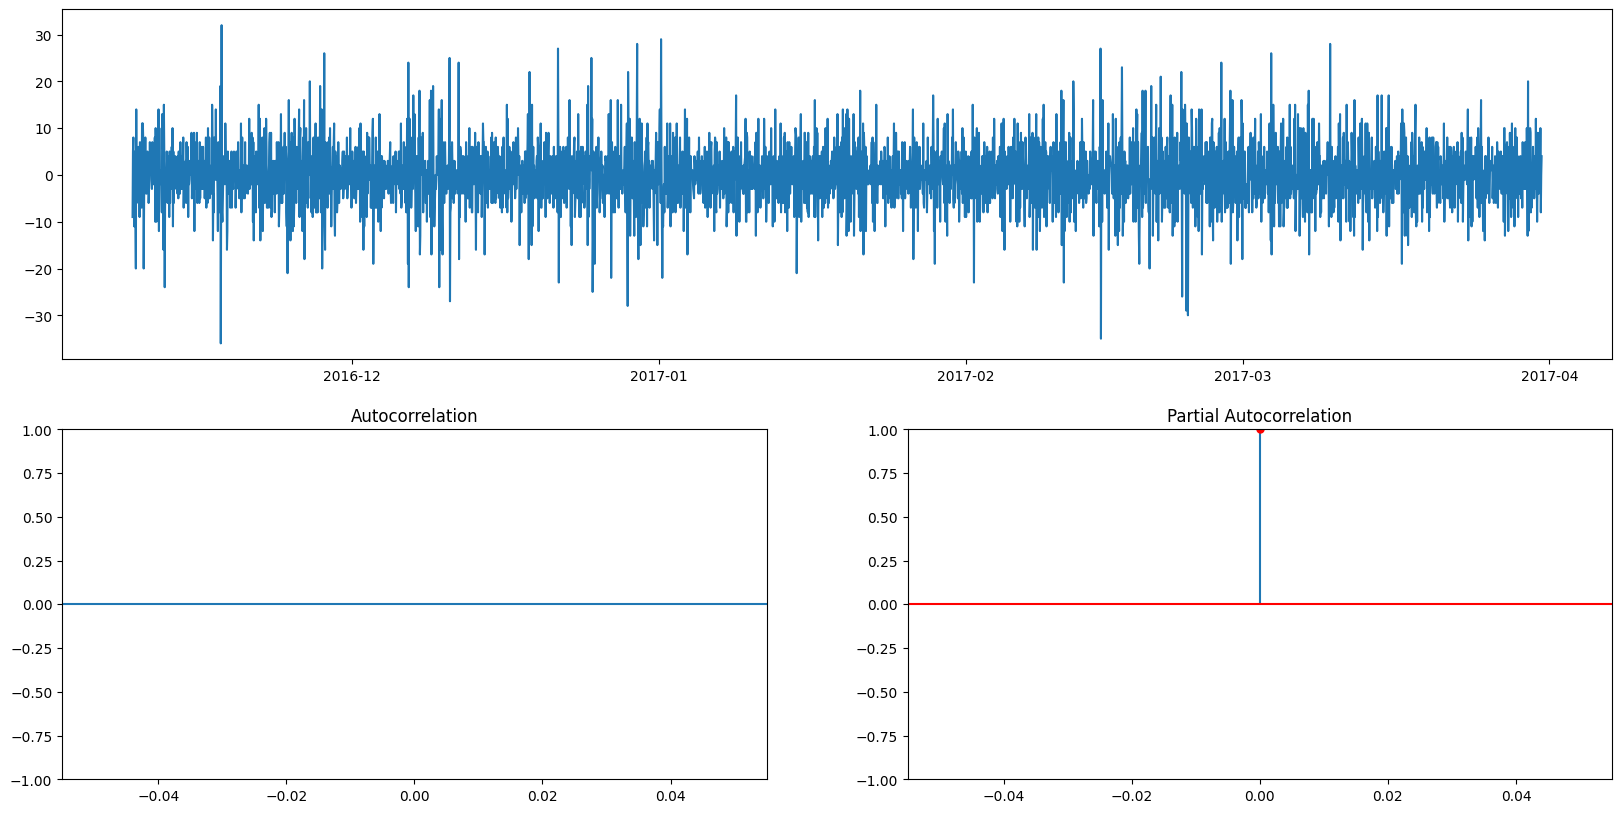

In [22]:
plot_autocorrelation(data_continua["MP2.5"],d=1,D=0,m=24)

Avaliando a Estacionaridade

**************
O p-valor deve ser menor que 0,05 para que possamos ter 95% de confiança de que a série é estacionária.

Idealmente, o p-valor deve ser muito menor que 0,05.
*************
seasonal_order=(P,1,Q,24)

In [23]:
result = adfuller(data_continua["MP2.5"])

print("ADF statistic:", result[0])
print("p-value:", result[1])

ADF statistic: -6.677629191689672
p-value: 4.423892863798992e-09


Apesar do teste rejeitar a hipótese não estacionária, os resultados tem mostrado que existe uma variação sazonal nos dados. Provavelmente a série não é tão estacionária. Dessa forma, serão testados diferenciações no ajuste dos parâmetros do SARIMAX.

### 6. Selecionando dados utilizados e incluindo variáveis sazonais

In [24]:
data_50 = data.copy()

In [25]:
# Foram avaliadas diferentes features sazonais (ciclos diários, semanais e mensal) com o objetivo de melhorar a reprodução do modelo.
def cyclical_time_features(df):
    """
    Adiciona termos ciclicos como features exógenas
    df -> data

    """

    df = df.copy()

    df["month_sin"] = np.sin(2 * np.pi * df.index.month / 12)
    df["month_cos"] = np.cos(2 * np.pi * df.index.month / 12)


    df["weekday_sin"] = np.sin(2 * np.pi * df.index.dayofweek / 7)
    df["weekday_cos"] = np.cos(2 * np.pi * df.index.dayofweek / 7)


    df["hour_sin"] = np.sin(2 * np.pi * df.index.hour / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df.index.hour / 24)

    return df

In [26]:
data_50 = cyclical_time_features(data_50)

In [27]:
# Também foi avaliada a inclusão de séries de Fourier. Os resultados demonstram que existe uma tendência de piora na reprodução do modelo nos meses de inverno.
def fourier_features(df, period=365.25, order=3, prefix="year"):
    """
    Adiciona termos de Fourier usando o calendário real.
    period:
        365.25 -> sazonalidade anual
    order:
        número de harmônicas
    prefix:
        nome das colunas criadas
    """

    df = df.copy()

    # dia do ano
    t = (df.index.dayofyear + df.index.hour / 24)

    for k in range(1, order + 1):

        df[f"{prefix}_sin_{k}"] = np.sin(
            2 * np.pi * k * t / period
        )

        df[f"{prefix}_cos_{k}"] = np.cos(
            2 * np.pi * k * t / period
        )

    return df

In [28]:
# Fourier anual
data_50 = fourier_features(
    data_50,
    period=365.25,
    order=3,
    prefix="year"
)

<Axes: xlabel='time'>

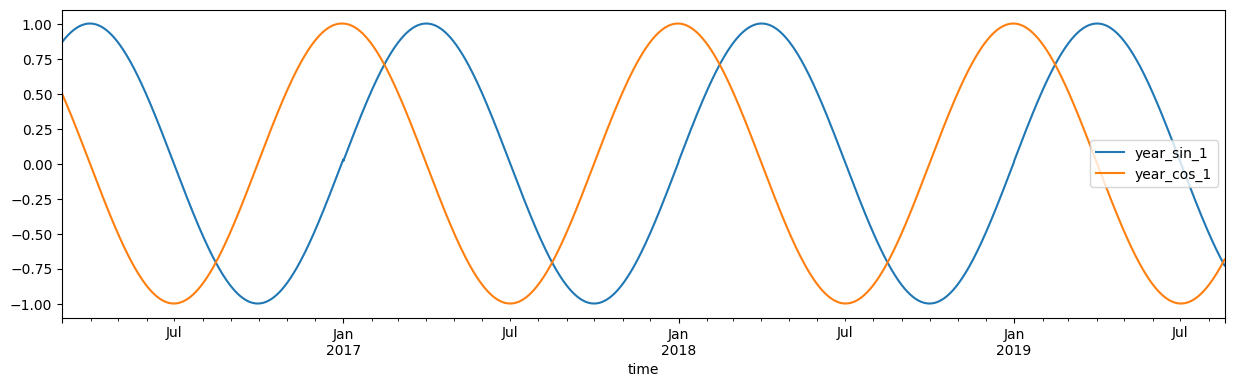

In [29]:
data_50[
    ["year_sin_1", "year_cos_1"]
].plot(figsize=(15,4))

In [30]:
data_50.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,hour_cos,year_sin_1,year_cos_1,year_sin_2,year_cos_2,year_sin_3,year_cos_3
time,,,,,,,,,,,,,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.000000,1.000000,0.867099,0.498137,0.863867,-0.503720,-0.006451,-0.999979
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915,1.0,6.123234e-17,0.781831,0.62349,0.258819,0.965926,0.867455,0.497515,0.863144,-0.504958,-0.008601,-0.999963
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.500000,0.866025,0.867812,0.496893,0.862419,-0.506194,-0.010751,-0.999942
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623,1.0,6.123234e-17,0.781831,0.62349,0.707107,0.707107,0.868168,0.496271,0.861693,-0.507430,-0.012901,-0.999917
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984,1.0,6.123234e-17,0.781831,0.62349,0.866025,0.500000,0.868523,0.495649,0.860965,-0.508665,-0.015052,-0.999887


### 7. Separando conjunto de treino, validação e teste

In [31]:
def split_temporal_sarimax(
    df,
    features,
    target,
    train_end="2018-01-01",
    val_end="2019-01-01"
):
    """
    Separação do conjunto de dados em: Treino, Teste e Validação

    """

    df = df.copy()
    df = df.sort_index()

    train = df.loc[df.index < train_end].copy()

    val = df.loc[
        (df.index >= train_end) &
        (df.index < val_end)
    ].copy()

    test = df.loc[df.index >= val_end].copy()

    exog_train = train[features]
    y_train = train[target]

    exog_val = val[features]
    y_val = val[target]

    exog_test = test[features]
    y_test = test[target]

    print("train:", train.shape, train.index.min(), train.index.max())
    print("val  :", val.shape, val.index.min(), val.index.max())
    print("test :", test.shape, test.index.min(), test.index.max())

    return exog_train, exog_val, exog_test, y_train, y_val, y_test

In [32]:
# Apesar de ter testado diferentes combinações de variáveis exógenas,
# modelo final melhor ajustado contem temp, umi, prec, wind
features_modelo = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "wind_speed_10m"]

target = "MP2.5"

exog_train, exog_val, exog_test, y_train, y_val, y_test = split_temporal_sarimax(
    data_50,
    features_modelo,
    target,
    train_end="2018-01-01",
    val_end="2019-01-01"
)


train: (16104, 17) 2016-03-01 00:00:00+00:00 2017-12-31 23:00:00+00:00
val  : (8760, 17) 2018-01-01 00:00:00+00:00 2018-12-31 23:00:00+00:00
test : (5499, 17) 2019-01-01 00:00:00+00:00 2019-08-18 02:00:00+00:00


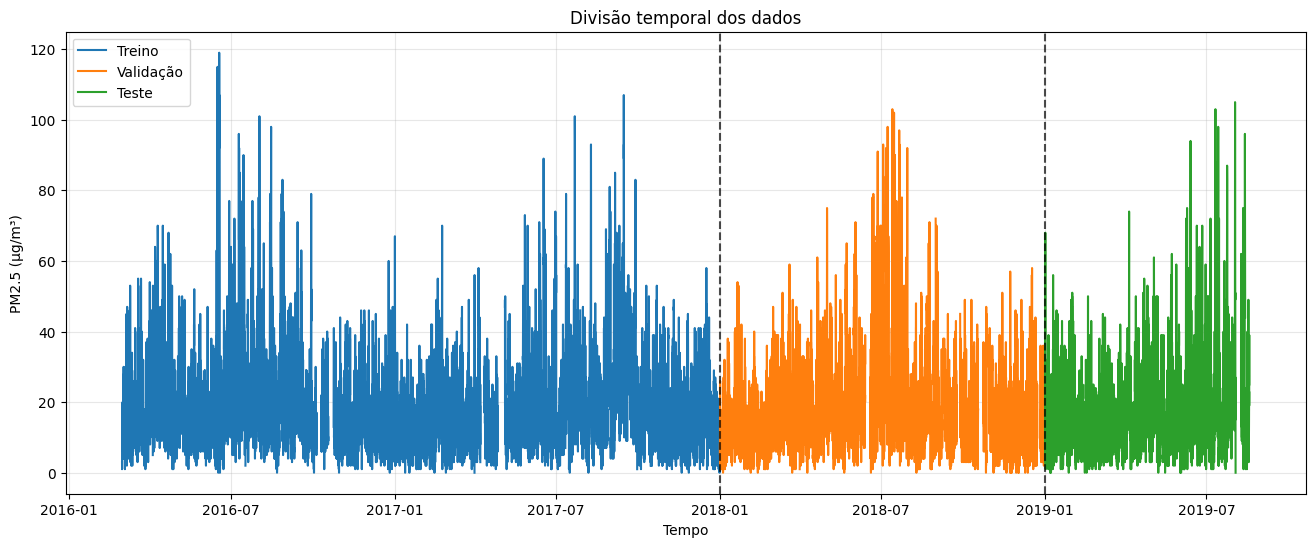

In [33]:
plt.figure(figsize=(16,6))

plt.plot(
    y_train,
    label="Treino",
    color="tab:blue"
)

plt.plot(
    y_val,
    label="Validação",
    color="tab:orange"
)

plt.plot(
    y_test,
    label="Teste",
    color="tab:green"
)

plt.axvline(
    y_val.index[0],
    color="black",
    linestyle="--",
    alpha=0.7
)

plt.axvline(
    y_test.index[0],
    color="black",
    linestyle="--",
    alpha=0.7
)

plt.title("Divisão temporal dos dados")
plt.ylabel("PM2.5 (µg/m³)")
plt.xlabel("Tempo")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 8. Baseline simples

In [34]:
# Seasonal Naive (24h) - utilizado nas rodas simples do modelo (item 9.1)
# observado nas primeiras 24h do teste
y_true = y_val.iloc[:24]

# Baseline = ultimas 24h do treino
y_baseline = y_train.iloc[-24:].copy()

y_baseline.index = y_true.index

mae_baseline = mean_absolute_error(y_true, y_baseline)
rmse_baseline = root_mean_squared_error(y_true, y_baseline)
r2_baseline = r2_score(y_true, y_baseline)

print(f"Baseline 24h - MAE : {mae_baseline:.3f}")
print(f"Baseline 24h - RMSE: {rmse_baseline:.3f}")
print(f"Baseline 24h - R²  : {r2_baseline:.3f}")

Baseline 24h - MAE : 5.375
Baseline 24h - RMSE: 7.536
Baseline 24h - R²  : -0.304


### 9. Modelagem

**9.1 Modelo único para testes**

In [35]:
# usando melhores parâmetros testados
order = (1,0,1)
seasonal_order = (0,1,1,24)

# enforce_stationarity=False -> utilizado por conta da presença de gaps e pela estratégia de retreinamento para avaliação
# enforce_invertibility=False -> também por conta do retreinamento para avaliação e também pq em alguns testes o ma.S.L24 < -1

model = SARIMAX(
    y_train,
    exog=exog_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

/home/izabel/.pyenv/versions/respira_sp/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/home/izabel/.pyenv/versions/respira_sp/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [36]:
results = model.fit()

In [37]:
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              MP2.5   No. Observations:                16104
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 24)   Log Likelihood              -50432.232
Date:                            Fri, 19 Jun 2026   AIC                         100880.464
Time:                                    12:57:07   BIC                         100941.934
Sample:                                03-01-2016   HQIC                        100900.791
                                     - 12-31-2017                                         
Covariance Type:                              opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
temperature_2m           0.0513      0.092      0.560      0.576      -0.128       0.231
relat

In [38]:
# previsão das próximas 24h
forecast_24h = results.get_forecast(
    steps=24,
    exog=exog_val.iloc[:24]
)

forecast_mean = forecast_24h.predicted_mean
conf_int = forecast_24h.conf_int()

index_forecast = y_val.index[:24]

forecast_mean.index = index_forecast
conf_int.index = index_forecast

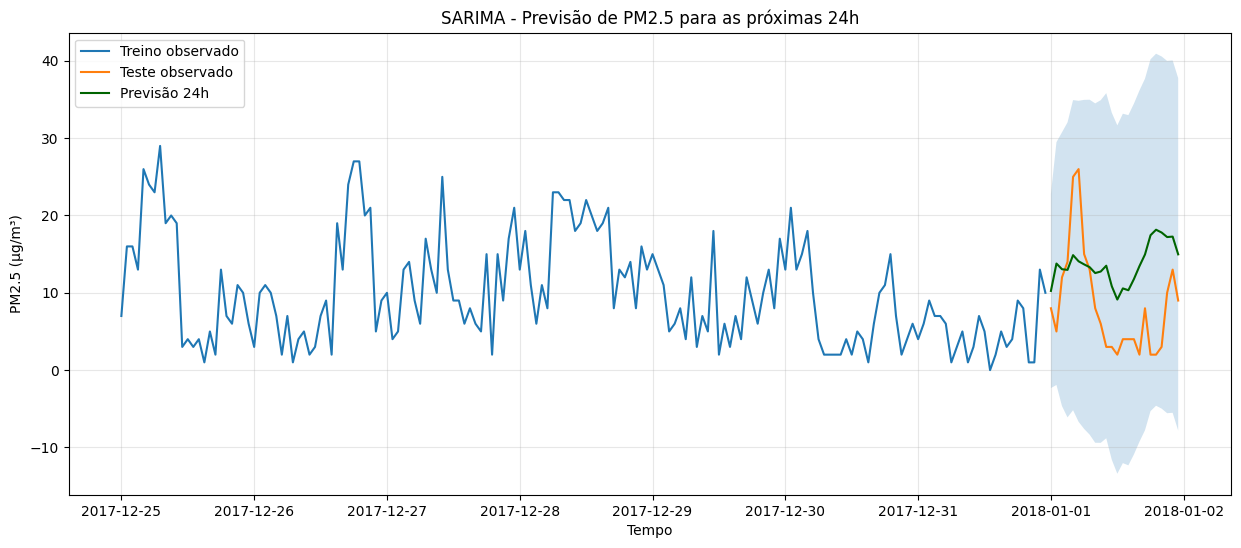

In [39]:
# Figura
plt.figure(figsize=(15, 6))

# últimos dias observados
plt.plot(
    y_train.iloc[-24*7:],
    label="Treino observado"
)

# comparar somente com +24h
plt.plot(
    y_val.iloc[:24],
    label="Teste observado"
)


plt.plot(
    forecast_mean,
    label="Previsão 24h",
    color="darkgreen"
)


plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.2
)

plt.title("SARIMA - Previsão de PM2.5 para as próximas 24h")
plt.xlabel("Tempo")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [40]:
error_mae = mean_absolute_error(
                y_true = y_val.iloc[:24],
                y_pred = forecast_mean
            )
print(f"Test error (mae): {error_mae}")

Test error (mae): 7.355910828352705


In [41]:
error_rmse = root_mean_squared_error(
    y_true=y_val.iloc[:24],
    y_pred=forecast_mean
)

print(f"Test error (RMSE): {error_rmse:.3f}")

Test error (RMSE): 8.583


In [42]:
r2 = r2_score(
    y_true=y_val.iloc[:24],
    y_pred=forecast_mean
)

print(f"R²: {r2:.4f}")

R²: -0.6909


**Avaliação dos resíduos do modelo**

In [43]:
# avaliando os resíduos
residuals = pd.Series(
    results.resid,
    index=y_train.index,
    name="residuals"
)

residuals = residuals.dropna()

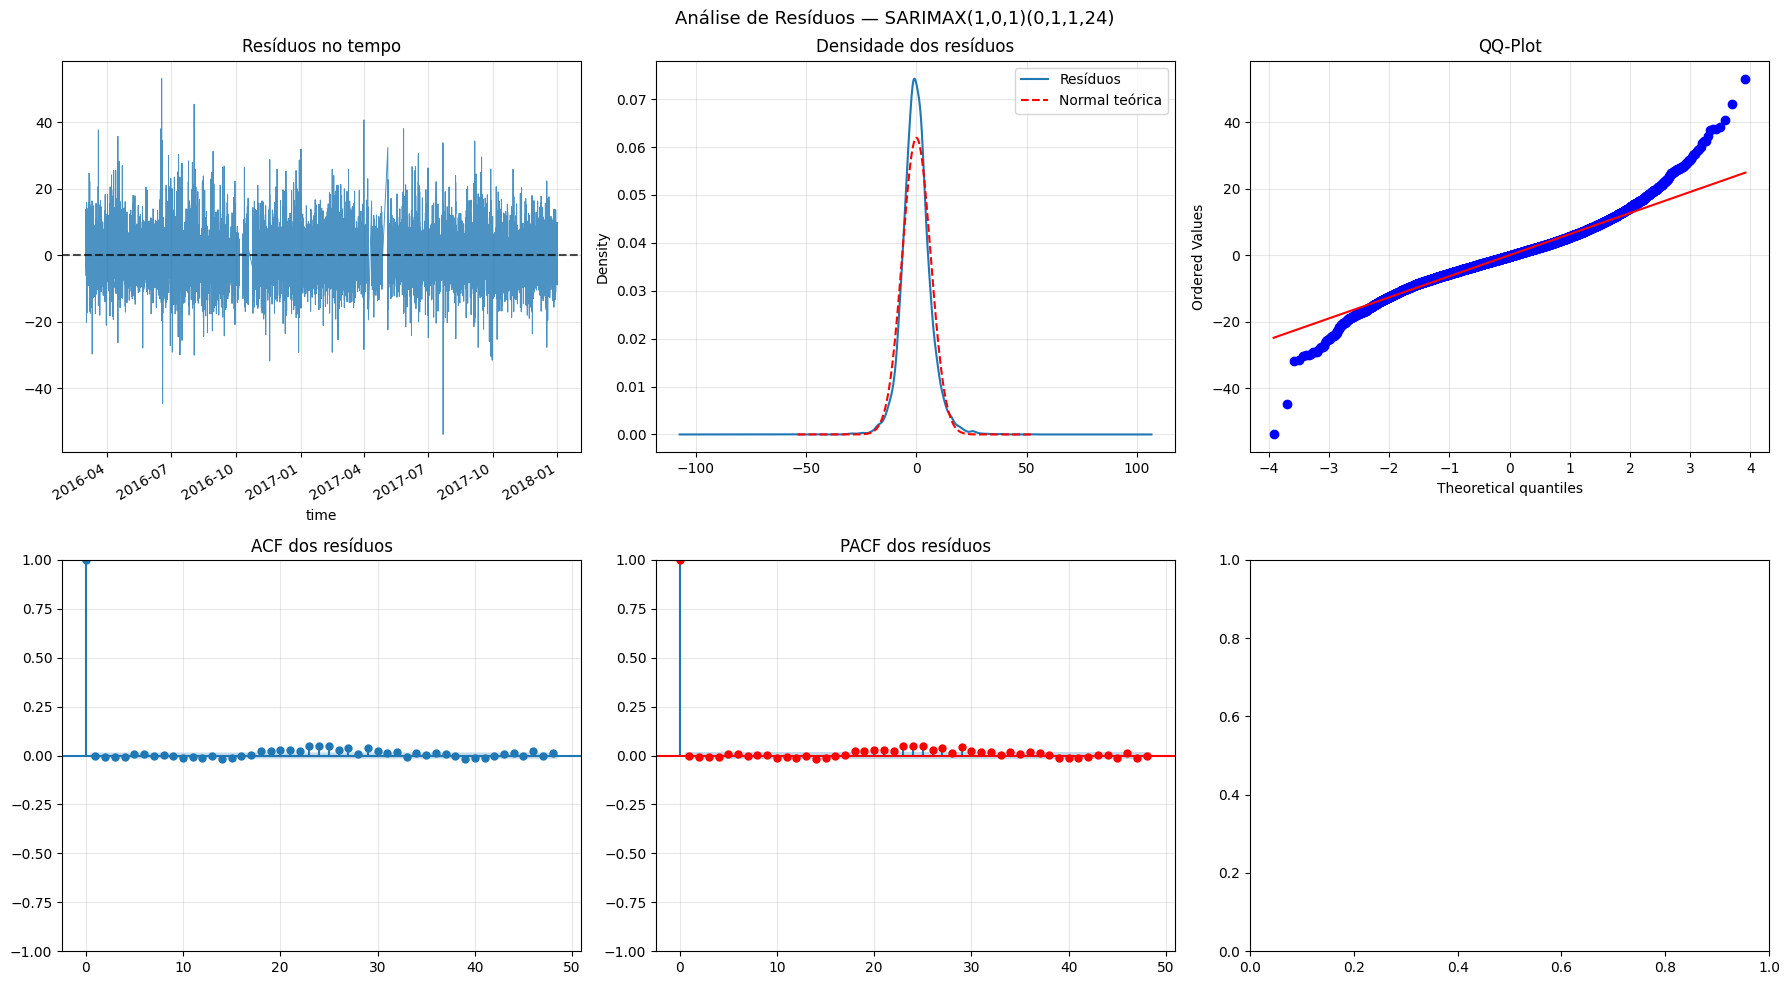

Média   : -0.0020  (ideal ≈ 0)
Std     : 6.4399
Skew    : 0.3751  (ideal ≈ 0)
Kurtosis: 3.2459  (ideal ≈ 0)


In [44]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Análise de Resíduos — SARIMAX(1,0,1)(0,1,1,24)", fontsize=13)


residuals.plot(ax=axes[0, 0], linewidth=0.7, alpha=0.8)
axes[0, 0].axhline(0, color="black", linestyle="--", alpha=0.7)
axes[0, 0].set_title("Resíduos no tempo")
axes[0, 0].grid(alpha=0.3)



residuals.plot(kind="kde", ax=axes[0, 1], label="Resíduos")
x = np.linspace(residuals.min(), residuals.max(), 200)
axes[0, 1].plot(
    x,
    stats.norm.pdf(x, residuals.mean(), residuals.std()),
    "r--", label="Normal teórica"
)
axes[0, 1].set_title("Densidade dos resíduos")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)



stats.probplot(residuals, dist="norm", plot=axes[0, 2])
axes[0, 2].set_title("QQ-Plot")
axes[0, 2].grid(alpha=0.3)



plot_acf(residuals, lags=48, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title("ACF dos resíduos")
axes[1, 0].grid(alpha=0.3)


plot_pacf(residuals, lags=48, method="ywm", ax=axes[1, 1], color="r")
axes[1, 1].set_title("PACF dos resíduos")
axes[1, 1].grid(alpha=0.3)



plt.tight_layout()
plt.show()


print(f"Média   : {residuals.mean():.4f}  (ideal ≈ 0)")
print(f"Std     : {residuals.std():.4f}")
print(f"Skew    : {residuals.skew():.4f}  (ideal ≈ 0)")
print(f"Kurtosis: {residuals.kurtosis():.4f}  (ideal ≈ 0)")

**Análise dos resíduos**
- Resíduos — média bem próxima de zero e comportamento aparentemente normal
- Skew - assimetria leve
- ACF/PACF - pequneo pico em 24h
- QQ-plot - o modelo subestima a variabilidade em eventos extremos (poluição intensa).

**8.2 Avaliação de todo o conjunto de validação** 

In [45]:
def walk_forward_sarimax(
    y_train,
    y_test,
    exog_train,
    exog_test,
    order=(1, 0, 1),
    seasonal_order=(0, 1, 1, 24),
    horizon=24,
    step=24*7,
    start_inicial=0,
    output_file="walk_forward_parcial.csv"):

    """
    Realiza validação walk-forward para o modelo SARIMAX com variáveis exógenas.

    A cada iteração, o conjunto de treino é expandido e uma previsão para os
    próximos `horizon` passos é gerada. O desempenho é comparado com um
    baseline sazonal simples, que assume que os próximos valores serão iguais
    aos observados nas últimas `horizon` observações.
    """


    resultados = []

    y_total = pd.concat([y_train, y_test])
    exog_total = pd.concat([exog_train, exog_test])

    n_test = len(y_test)

    for start in range(start_inicial, n_test - horizon + 1, step):

        print(f"Rodando previsão {start} até {start + horizon} de {n_test}...")

        # treino cresce a cada iteração
        y_train_i = y_total.iloc[:len(y_train) + start]
        exog_train_i = exog_total.iloc[:len(y_train) + start]

        # janela futura de validação
        y_true_i = y_test.iloc[start:start + horizon]
        exog_future_i = exog_test.iloc[start:start + horizon]

        # verificando NaN em exgógenas
        if exog_train_i.isna().any().any():
            raise ValueError("Existem NaNs em exog_train_i.")

        if exog_future_i.isna().any().any():
            raise ValueError("Existem NaNs em exog_future_i.")

        mask_eval = y_true_i.notna()

        if mask_eval.sum() == 0:
            continue

        model = SARIMAX(
            y_train_i,
            exog=exog_train_i,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        results = model.fit(disp=False)

        forecast = results.get_forecast(
            steps=horizon,
            exog=exog_future_i
        )

        y_pred_i = forecast.predicted_mean
        y_pred_i.index = y_true_i.index

        # baseline: previsão das próximas 24h = últimas 24h
        y_baseline_i = y_total.iloc[
            len(y_train) + start - horizon : len(y_train) + start
        ].copy()

        y_baseline_i.index = y_true_i.index

        #metricas do modelo
        mae = mean_absolute_error(
            y_true_i[mask_eval],
            y_pred_i[mask_eval]
        )


        rmse = np.sqrt(mean_squared_error(
            y_true_i[mask_eval],
            y_pred_i[mask_eval]
        ))

        r2 = r2_score(
            y_true_i[mask_eval],
            y_pred_i[mask_eval]
        ) if mask_eval.sum() > 1 else np.nan

        #metricas do baseline
        mae_baseline = mean_absolute_error(
            y_true_i[mask_eval],
            y_baseline_i[mask_eval]
        )

        rmse_baseline = np.sqrt(mean_squared_error(
            y_true_i[mask_eval],
            y_baseline_i[mask_eval]
        ))

        r2_baseline = r2_score(
            y_true_i[mask_eval],
            y_baseline_i[mask_eval]
        ) if mask_eval.sum() > 1 else np.nan

        melhora_mae = (
            100 * (mae_baseline - mae) / mae_baseline
            if mae_baseline != 0 else np.nan
        )

        melhora_rmse = (
            100 * (rmse_baseline - rmse) / rmse_baseline
            if rmse_baseline != 0 else np.nan
        )

        resultados.append({
            "start": start,
            "inicio_previsao": y_true_i.index[0],
            "fim_previsao": y_true_i.index[-1],
            "mes": str(y_true_i.index[0].to_period("M")),
            "n_obs": mask_eval.sum(),

            "mae_sarimax": mae,
            "rmse_sarimax": rmse,
            "r2_sarimax": r2,

            "mae_baseline": mae_baseline,
            "rmse_baseline": rmse_baseline,
            "r2_baseline": r2_baseline,

            "melhora_mae_%": melhora_mae,
            "melhora_rmse_%": melhora_rmse
        })

        #salvando para evitar perder
        pd.DataFrame(resultados).to_csv(output_file,index=False)

    return pd.DataFrame(resultados)

In [ ]:
# df_walk = walk_forward_sarimax(
#     y_train=y_train,
#     y_test=y_val,
#     exog_train=exog_train,
#     exog_test=exog_val,
#     order=(1, 0, 1),
#     seasonal_order=(0, 1, 1, 24),
#     horizon=24,
#     step=24*21,
#     start_inicial=0,
#     output_file="../results/walk_forward_parcial_temp_umi_prec_wind_101_val.csv"
# )

# df_walk

In [47]:
# df_walk[["mae_sarimax", "rmse_sarimax", "r2_sarimax",
#          "mae_baseline", "melhora_mae_%"]].describe()

In [48]:
# plt.figure(figsize=(14, 5))
# plt.plot(df_walk["inicio_previsao"], df_walk["mae"], marker="o")
# plt.title("Walk-forward validation - MAE por janela de previsão")
# plt.xlabel("Início da previsão")
# plt.ylabel("MAE")
# plt.grid(True, alpha=0.3)
# plt.show()

**8.3 Avaliação de todo o conjunto de teste** 

In [49]:
# df_walk = walk_forward_sarimax(
#     y_train=y_train,
#     y_test=y_test,
#     exog_train=exog_train,
#     exog_test=exog_test,
#     order=(1, 0, 1),
#     seasonal_order=(0, 1, 1, 24),
#     horizon=24,
#     step=24*21,
#     start_inicial=0,
#     output_file="../results/walk_forward_parcial_temp_umi_prec_wind_101_teste.csv"
# )

# df_walk

In [50]:
# df_walk[["mae_sarimax", "rmse_sarimax", "r2_sarimax",
#          "mae_baseline", "melhora_mae_%"]].describe()

In [51]:
# plt.figure(figsize=(14, 5))
# plt.plot(df_walk["inicio_previsao"], df_walk["mae"], marker="o")
# plt.title("Walk-forward validation - MAE por janela de previsão")
# plt.xlabel("Início da previsão")
# plt.ylabel("MAE")
# plt.grid(True, alpha=0.3)
# plt.show()

### 9. Experimentos - Resultados



**9.1 Avaliação da melhor configuração - order(1,0,1) seazonal_order(0,1,1,24)**

  - 100% dos dados entre 2016-2019, features (temp, umi, prec, wind), sem interpolação
      - train: (16104, 7) 2016-03-01 00:00:00+00:00 2017-12-31 23:00:00+00:00
      - val  : (8760, 7) 2018-01-01 00:00:00+00:00 2018-12-31 23:00:00+00:00
      - test : (5499, 7) 2019-01-01 00:00:00+00:00 2019-08-18 02:00:00+00:00


O Experimento order(1,0,1) melhorou o experimento de controle e passará a ser considerado o melhor experimento para o SARIMAX com índices:

- Resultados obtidos no conjunto de validação em média:

    - MAE: 7.13 µg/m³
    - RMSE: 8,61 µg/m³
    - R²: -0.26

- Resultados obtidos no conjunto de teste em média:

    - MAE: 7.55 µg/m³
    - RMSE: 9.75 µg/m³
    - R²: -0.41

In [52]:
#abrindo resultados do conjunto de validação
best_val = pd.read_csv('../results/walk_forward_parcial_temp_umi_prec_wind_101_val.csv')
best_val

,start,inicio_previsao,fim_previsao,mes,n_obs,mae_sarimax,rmse_sarimax,r2_sarimax,mae_baseline,rmse_baseline,r2_baseline,melhora_mae_%,melhora_rmse_%
0,0,2018-01-01 00:00:00+00:00,2018-01-01 23:00:00+00:00,2018-01,24,7.356550,8.583687,-0.691154,5.375000,7.536025,-0.303527,-36.866055,-13.902058
1,504,2018-01-22 00:00:00+00:00,2018-01-22 23:00:00+00:00,2018-01,24,5.621546,7.493182,-0.615844,8.666667,11.210114,-2.616488,35.136004,33.156954
2,1008,2018-02-12 00:00:00+00:00,2018-02-12 23:00:00+00:00,2018-02,24,4.567545,5.949813,0.064267,6.291667,7.305820,-0.410858,27.403259,18.560642
3,1512,2018-03-05 00:00:00+00:00,2018-03-05 23:00:00+00:00,2018-03,24,5.185316,7.380621,-0.122684,7.958333,10.370230,-1.216402,34.844203,28.828765
4,2016,2018-03-26 00:00:00+00:00,2018-03-26 23:00:00+00:00,2018-03,24,7.807811,8.842460,0.062961,8.958333,11.588428,-0.609388,12.843035,23.695775
5,2520,2018-04-16 00:00:00+00:00,2018-04-16 23:00:00+00:00,2018-04,24,6.053694,7.292270,-1.563614,4.416667,5.400617,-0.406093,-37.064770,-35.026595
6,3024,2018-05-07 00:00:00+00:00,2018-05-07 23:00:00+00:00,2018-05,24,5.162915,6.217419,-1.061860,8.666667,11.265730,-5.769516,40.427900,44.811218
7,3528,2018-05-28 00:00:00+00:00,2018-05-28 23:00:00+00:00,2018-05,24,5.269953,6.483349,-0.354791,7.375000,8.580501,-1.373007,28.543015,24.440907
8,4536,2018-07-09 00:00:00+00:00,2018-07-09 23:00:00+00:00,2018-07,24,14.736794,16.183952,0.420403,23.541667,28.085435,-0.745496,37.401227,42.375997
9,5040,2018-07-30 00:00:00+00:00,2018-07-30 23:00:00+00:00,2018-07,24,15.750406,19.635768,0.441684,16.875000,21.738024,0.315735,6.664261,9.670866


In [53]:
#abrindo resultados do conjunto de teste
best_test = pd.read_csv('../results/walk_forward_parcial_temp_umi_prec_wind_101_teste.csv')
best_test

,start,inicio_previsao,fim_previsao,mes,n_obs,mae_sarimax,rmse_sarimax,r2_sarimax,mae_baseline,rmse_baseline,r2_baseline,melhora_mae_%,melhora_rmse_%
0,0,2019-01-01 00:00:00+00:00,2019-01-01 23:00:00+00:00,2019-01,24,12.445241,18.217827,-0.157108,18.166667,24.262454,-1.052345,31.494087,24.913500
1,504,2019-01-22 00:00:00+00:00,2019-01-22 23:00:00+00:00,2019-01,24,8.019370,9.570993,-0.370098,12.500000,14.753531,-2.255589,35.845036,35.127438
2,1008,2019-02-12 00:00:00+00:00,2019-02-12 23:00:00+00:00,2019-02,24,4.570114,5.634869,-0.167657,4.708333,5.820223,-0.245738,2.935640,3.184661
3,1512,2019-03-05 00:00:00+00:00,2019-03-05 23:00:00+00:00,2019-03,22,6.161342,7.831001,0.172491,7.363636,10.045352,-0.361659,16.327460,22.043533
4,2016,2019-03-26 00:00:00+00:00,2019-03-26 23:00:00+00:00,2019-03,24,8.616169,11.246244,-1.225487,8.250000,10.916349,-1.096838,-4.438406,-3.022033
5,2520,2019-04-16 00:00:00+00:00,2019-04-16 23:00:00+00:00,2019-04,24,4.770842,5.825774,0.060088,6.458333,8.923284,-1.205106,26.128903,34.712671
6,3024,2019-05-07 00:00:00+00:00,2019-05-07 23:00:00+00:00,2019-05,24,7.690971,9.607728,0.257199,10.333333,12.379418,-0.233194,25.571246,22.389500
7,3528,2019-05-28 00:00:00+00:00,2019-05-28 23:00:00+00:00,2019-05,24,9.173040,12.723553,0.311661,15.000000,19.636276,-0.639472,38.846397,35.203840
8,4032,2019-06-18 00:00:00+00:00,2019-06-18 23:00:00+00:00,2019-06,24,6.046538,7.508422,-0.743975,7.541667,9.103571,-1.563695,19.824913,17.522230
9,4536,2019-07-09 00:00:00+00:00,2019-07-09 23:00:00+00:00,2019-07,24,5.217180,6.177138,0.103798,6.125000,7.618508,-0.363236,14.821552,18.919318


In [54]:
mae_medio = best_val["mae_sarimax"].mean()
rmse_medio = best_val["rmse_sarimax"].mean()
r2_medio = best_val["r2_sarimax"].mean()

print("Conjunto de Validação")
print(f"MAE médio  : {mae_medio:.3f}")
print(f"RMSE médio : {rmse_medio:.3f}")
print(f"R² médio   : {r2_medio:.3f}")

Conjunto de Validação
MAE médio  : 7.135
RMSE médio : 8.617
R² médio   : -0.268


In [55]:
mae_medio = best_test["mae_sarimax"].mean()
rmse_medio = best_test["rmse_sarimax"].mean()
r2_medio = best_test["r2_sarimax"].mean()

print("Conjunto de Teste")
print(f"MAE médio  : {mae_medio:.3f}")
print(f"RMSE médio : {rmse_medio:.3f}")
print(f"R² médio   : {r2_medio:.3f}")

Conjunto de Teste
MAE médio  : 7.306
RMSE médio : 9.487
R² médio   : -0.437


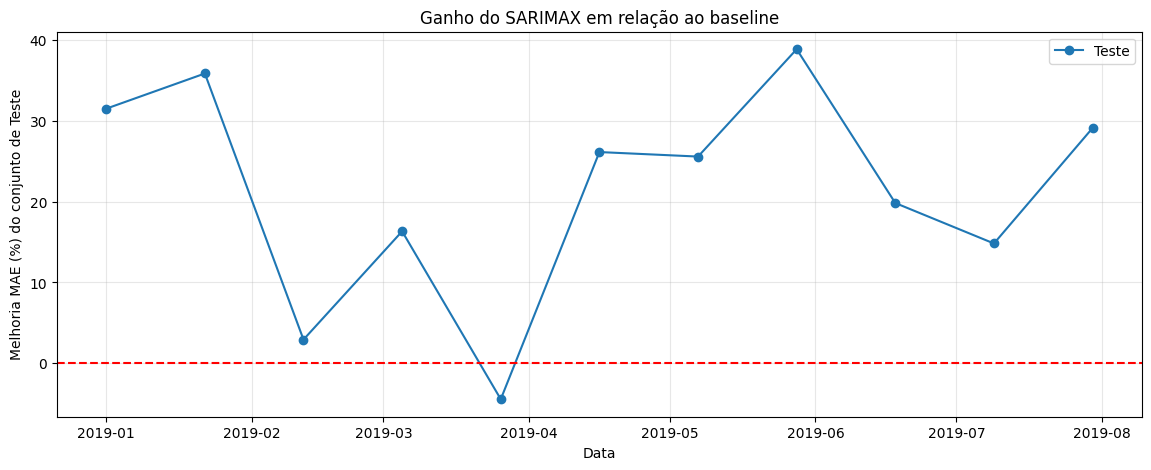

In [56]:
plt.figure(figsize=(14,5))

plt.plot(
    pd.to_datetime(best_test["inicio_previsao"]),
    best_test["melhora_mae_%"],
    marker="o",
    label="Teste"
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.ylabel("Melhoria MAE (%) do conjunto de Teste")
plt.xlabel("Data")
plt.title("Ganho do SARIMAX em relação ao baseline")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### **10. Memória de cálculo dos testes**



**Testes iniciais do conjunto de dados, features, interpolações**

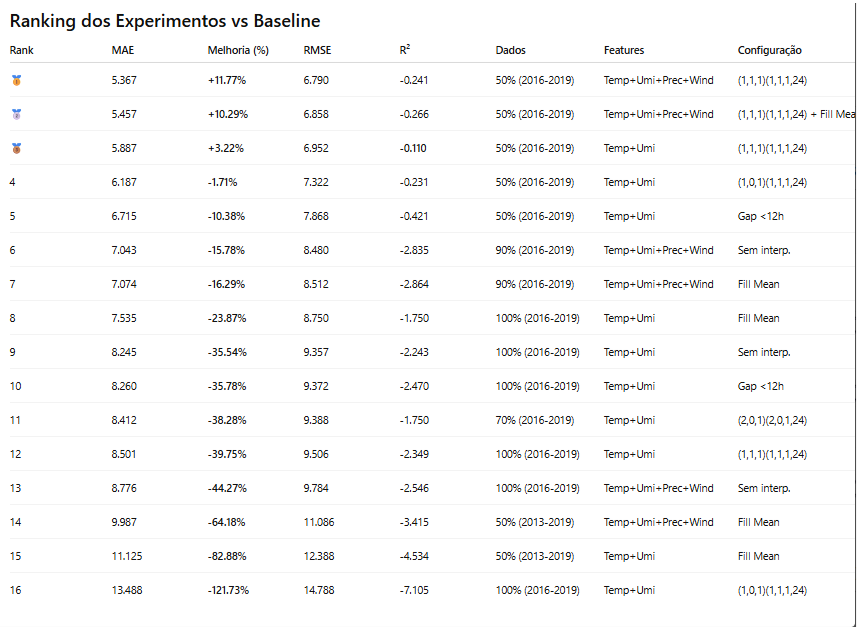

**Testes dos parâmetros do SARIMAX usando melhor conjunto de dados/features/interpolação**

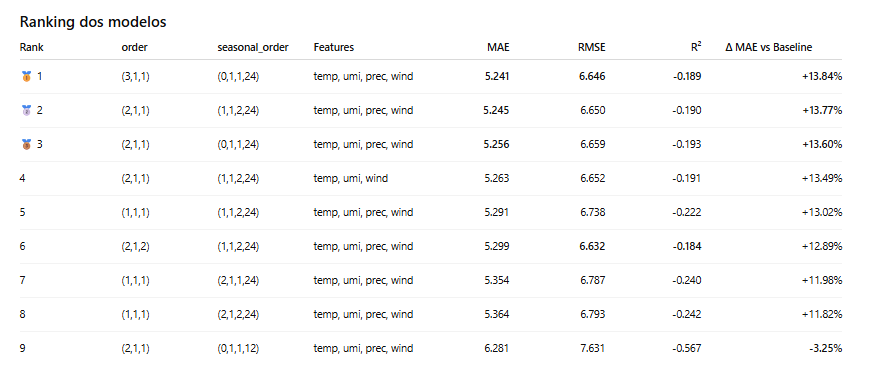